In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical


In [14]:
df = pd.read_csv("mnist_sample_1000.csv")

print(df.shape)
print(df.head())

(1000, 785)
   label   0   1   2   3   4   5   6  7   8  ...  774  775  776  777  778  \
0      0  25   1  10   0   0   0   7  0  11  ...  243  255  254  255  246   
1      7   0   0  11  11  10  27  26  0   6  ...    5   16   11   34    0   
2      6   0  13   0  20  51   6  10  0   0  ...  236  255  252  255  255   
3      4   0   8   0   9   4  21   1  0  19  ...   26   14    0   11    0   
4      4   0   6   0   5   0   0  18  0  36  ...   23    0    0    0    4   

   779  780  781  782  783  
0  255  255   14    0    0  
1    0    0   11    8    1  
2  225  255    0   17   17  
3    0    0    0   15   21  
4    1    0    0    0    0  

[5 rows x 785 columns]


In [15]:
y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 784)
y Shape: (1000,)


In [19]:
print("Minimum Pixel:", X.min())
print("Maximum Pixel:", X.max())



Minimum Pixel: 0
Maximum Pixel: 255


In [21]:
X = X / 255.0

In [22]:
X = X.reshape(-1, 28, 28, 1)

print(X.shape)

(1000, 28, 28, 1)


In [23]:
y = to_categorical(y, 10)

print(y.shape)

(1000, 10)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (800, 28, 28, 1)
Testing: (200, 28, 28, 1)


In [25]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



In [27]:
model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    verbose=1
)

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4775 - loss: 1.7361
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9025 - loss: 0.6559
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9987 - loss: 0.1982


In [28]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

Test Accuracy: 1.0
Test Loss: 0.09171733260154724


In [29]:
prediction = model.predict(X_test)

predicted_digit = np.argmax(prediction[0])
actual_digit = np.argmax(y_test[0])

print("Actual Digit:", actual_digit)
print("Predicted Digit:", predicted_digit)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Actual Digit: 1
Predicted Digit: 1


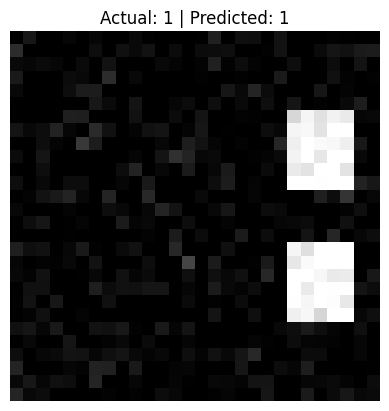

In [30]:
plt.imshow(X_test[0].reshape(28,28), cmap="gray")

plt.title(
    "Actual: " + str(actual_digit) +
    " | Predicted: " + str(predicted_digit)
)

plt.axis("off")
plt.show()